In [18]:
%load_ext autoreload
%autoreload 2

from scipy.integrate import odeint
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from htor.style import BLUE, RED, ORANGE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
def removal_rate_from_turnover_time(turnover_time):
    return np.log(2) / (turnover_time / 5)


def get_params(p5=1/3, p6=1/3, p7=1/3, p8=None, uv=1):
    rD = removal_rate_from_turnover_time(1/7)
    rm = removal_rate_from_turnover_time(4)
    rM = removal_rate_from_turnover_time(52)
    p2 = rD / rM
    p4 = rm / rM
    p8 = p8 or 1 / (5 * np.log(2))
    return dict(p1=p2, p2=p2, p3=p4, p4=p4, p5=p5, p6=p6, p7=p7, p8=p8, uv=uv)


def get_f(params):
    p1, p2, p3, p4 = params['p1'], params['p2'], params['p3'], params['p4']
    p5, p6, p7, p8 = params['p5'], params['p6'], params['p7'], params['p8']
    uv = params['uv']

    def f(x, t):
        D, m, a, M = x
        dD = p1 * uv / m - p2 * D
        dm = p3 * M * D - p4 * m
        da = p8 * D - p8
        dM = M * (p5 + p6 * a * D + p7 * D - 1)
        return [dD, dm, da, dM]

    return f


def get_steady_state(params):
    f = get_f(params)
    x0 = [1.0, 1.0, 1.0, 1.0]
    t = np.linspace(0, 1000, 2000)
    sol = odeint(f, x0, t)
    return sol[-1]


defaults = get_params()
x0 = get_steady_state(defaults)
print(f'steady state: D={x0[0]:.4f}, m={x0[1]:.4f}, α={x0[2]:.4f}, M={x0[3]:.4f}')

steady state: D=1.0000, m=1.0000, α=1.0000, M=1.0000


## Strategy: preparatory pM increase then abrupt reduction

1. Gradually increase pM 10-fold (over 10x the treatment duration)
2. Abruptly decrease pM 100-fold

Compare against abrupt pM reduction without preparation.

In [20]:
def prep_then_treatment(params, duration, pM_increase_fold=10, pM_reduction_fold=100,
                        prep_duration_multiple=10, n_prep_steps=100):
    """Three-phase: steady state → gradual pM increase → abrupt pM reduction.
    Returns t_prep, sol_prep, t_treat, sol_treat, pM_over_time."""
    p5_base = params['p5']
    t_prep_dur = duration * prep_duration_multiple

    x_current = get_steady_state(params)

    # Phase 1: gradual pM increase
    p5_values = np.linspace(p5_base, p5_base * pM_increase_fold, n_prep_steps)
    t_prep_all, sol_prep_all = [], []
    t_start = 0

    for i in range(n_prep_steps):
        dt = t_prep_dur / n_prep_steps
        t_step = np.linspace(t_start, t_start + dt, 10)
        p = params.copy()
        p['p5'] = p5_values[i]
        sol = odeint(get_f(p), x_current, t_step)
        t_prep_all.append(t_step)
        sol_prep_all.append(sol)
        x_current = sol[-1]
        t_start += dt

    t_prep = np.concatenate(t_prep_all)
    sol_prep = np.vstack(sol_prep_all)

    # Phase 2: abrupt pM reduction (relative to original baseline)
    p = params.copy()
    p['p5'] = p5_base / pM_reduction_fold
    t_treat = np.linspace(t_prep_dur, t_prep_dur + duration, 200)
    sol_treat = odeint(get_f(p), x_current, t_treat)

    # Reconstruct pM over time
    p5_per_step = np.repeat(p5_values, 10)
    p5_treat = np.full(len(t_treat), p['p5'])

    return t_prep, sol_prep, t_treat, sol_treat, np.concatenate([p5_per_step, p5_treat])


def abrupt_treatment(params, baseline_duration, treat_duration, pM_reduction_fold=100):
    """Two-phase: baseline for baseline_duration → abrupt pM reduction for treat_duration."""
    x0 = get_steady_state(params)

    t1 = np.linspace(0, baseline_duration, 200)
    sol1 = odeint(get_f(params), x0, t1)

    p = params.copy()
    p['p5'] = params['p5'] / pM_reduction_fold
    t2 = np.linspace(baseline_duration, baseline_duration + treat_duration, 200)
    sol2 = odeint(get_f(p), sol1[-1], t2)

    # pM over time
    pM = np.concatenate([np.full(len(t1), params['p5']), np.full(len(t2), p['p5'])])

    return t1, sol1, t2, sol2, pM

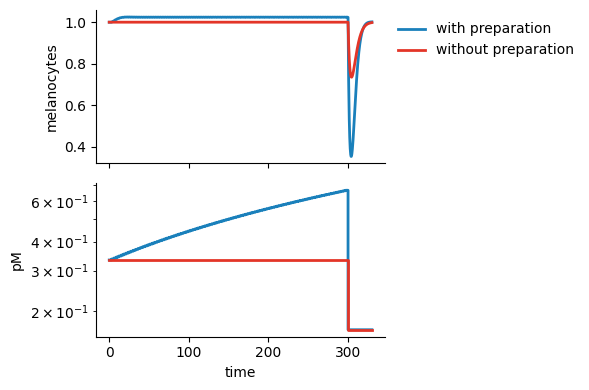

In [24]:
duration = 30
pM_reduction_fold = 2
pM_increase_fold = 2
prep_duration_multiple = 10

t_prep, sol_prep, t_treat, sol_treat, pM_full = prep_then_treatment(
    defaults, duration, pM_increase_fold=pM_increase_fold,
    pM_reduction_fold=pM_reduction_fold, prep_duration_multiple=prep_duration_multiple)

# Abrupt: baseline lasts as long as the prep phase, then treat for same duration
prep_dur = duration * prep_duration_multiple
t1_abr, sol1_abr, t2_abr, sol2_abr, pM_abr = abrupt_treatment(
    defaults, baseline_duration=prep_dur, treat_duration=duration,
    pM_reduction_fold=pM_reduction_fold)

# Full arrays
t_full = np.concatenate([t_prep, t_treat])
M_full = np.concatenate([sol_prep[:, 3], sol_treat[:, 3]])

t_abr_full = np.concatenate([t1_abr, t2_abr])
M_abr_full = np.concatenate([sol1_abr[:, 3], sol2_abr[:, 3]])

fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

# Top: melanocytes
ax = axs[0]
ax.plot(t_full, M_full, color=BLUE, lw=2, label='with preparation')
ax.plot(t_abr_full, M_abr_full, color=RED, lw=2, label='without preparation')
ax.set_ylabel('melanocytes')
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
sns.despine(ax=ax)

# Bottom: pM
ax = axs[1]
ax.plot(t_full, pM_full, color=BLUE, lw=2)
ax.plot(t_abr_full, pM_abr, color=RED, lw=2)
ax.set_ylabel('pM')
ax.set_xlabel('time')
ax.set_yscale('log')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

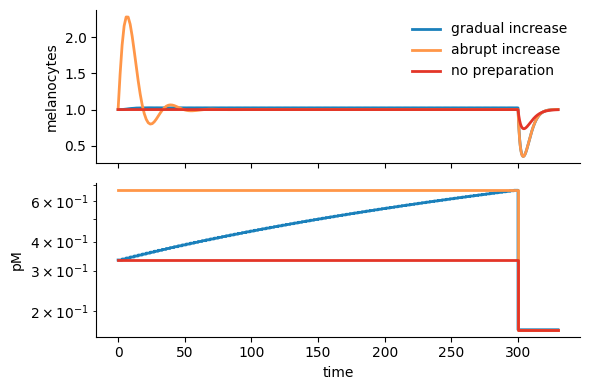

In [25]:
# Abrupt increase then abrupt reduction: pM jumps up, holds, then drops
def abrupt_increase_then_treatment(params, prep_duration, treat_duration,
                                   pM_increase_fold=2, pM_reduction_fold=100):
    """Three-phase: baseline → abrupt pM increase → abrupt pM reduction."""
    p5_base = params['p5']
    x0 = get_steady_state(params)

    # Phase 1: abrupt pM increase
    p = params.copy()
    p['p5'] = p5_base * pM_increase_fold
    t1 = np.linspace(0, prep_duration, 200)
    sol1 = odeint(get_f(p), x0, t1)

    # Phase 2: abrupt pM reduction (relative to original baseline)
    p2 = params.copy()
    p2['p5'] = p5_base / pM_reduction_fold
    t2 = np.linspace(prep_duration, prep_duration + treat_duration, 200)
    sol2 = odeint(get_f(p2), sol1[-1], t2)

    t_full = np.concatenate([t1, t2])
    sol_full = np.vstack([sol1, sol2])
    pM = np.concatenate([np.full(len(t1), p['p5']), np.full(len(t2), p2['p5'])])

    return t_full, sol_full, pM


t_abr_inc, sol_abr_inc, pM_abr_inc = abrupt_increase_then_treatment(
    defaults, prep_duration=prep_dur, treat_duration=duration,
    pM_increase_fold=pM_increase_fold, pM_reduction_fold=pM_reduction_fold)

fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax = axs[0]
ax.plot(t_full, M_full, color=BLUE, lw=2, label='gradual increase')
ax.plot(t_abr_inc, sol_abr_inc[:, 3], color=ORANGE, lw=2, label='abrupt increase')
ax.plot(t_abr_full, M_abr_full, color=RED, lw=2, label='no preparation')
ax.set_ylabel('melanocytes')
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
sns.despine(ax=ax)

ax = axs[1]
ax.plot(t_full, pM_full, color=BLUE, lw=2)
ax.plot(t_abr_inc, pM_abr_inc, color=ORANGE, lw=2)
ax.plot(t_abr_full, pM_abr, color=RED, lw=2)
ax.set_ylabel('pM')
ax.set_xlabel('time')
ax.set_yscale('log')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## Adaptive treatment with accelerated memory erasure

1. Set ρ₈ to 5x baseline (faster chromatin resetting)
2. Adaptive pM cycling: turn treatment OFF when M crosses steady state (M=1), turn ON when M reaches peak/trough (dM/dt=0)

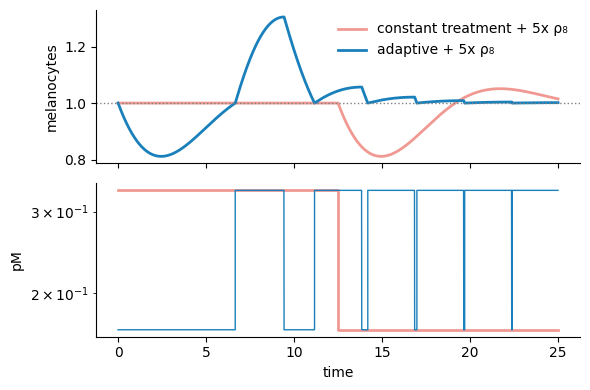

In [42]:
from scipy.integrate import solve_ivp

def adaptive_treatment(params, total_duration, pM_reduction_fold=2, p8_fold=5,
                       initial_treat_duration=1.0):
    """Adaptive pM cycling with accelerated memory erasure.
    
    Starts with treatment ON for initial_treat_duration to perturb from steady state.
    Then: treatment OFF when M crosses M*=1, ON when M reaches peak/trough (dM/dt sign change).
    """
    p = params.copy()
    p['p8'] = params['p8'] * p8_fold
    p5_base = params['p5']
    p5_treat = p5_base / pM_reduction_fold
    M_star = 1.0

    x = get_steady_state(params)

    def f_ivp(t, y):
        return get_f(p)(y, t)

    # Phase 0: initial treatment kick to break out of steady state
    p['p5'] = p5_treat
    sol0 = solve_ivp(f_ivp, (0, initial_treat_duration), x, max_step=0.1)
    
    t_all = [sol0.t]
    sol_all = [sol0.y.T]
    pM_all = [np.full(len(sol0.t), p5_treat)]

    x = sol0.y[:, -1]
    t_start = initial_treat_duration
    treatment_on = True  # start ON, first event will be M crossing 1

    def M_crosses_one(t, y):
        return y[3] - M_star
    M_crosses_one.terminal = True
    M_crosses_one.direction = 0

    max_segments = 500
    for _ in range(max_segments):
        if t_start >= total_duration:
            break

        p['p5'] = p5_treat if treatment_on else p5_base

        if treatment_on:
            # Run until M crosses 1
            sol = solve_ivp(f_ivp, (t_start, total_duration), x,
                            max_step=0.1, events=[M_crosses_one])
            t_all.append(sol.t)
            sol_all.append(sol.y.T)
            pM_all.append(np.full(len(sol.t), p['p5']))
            x = sol.y[:, -1]
            t_start = sol.t[-1]
            if sol.t_events[0].size > 0:
                treatment_on = False
        else:
            # Run a small step and check for dM/dt sign change
            dt_seg = min(0.5, total_duration - t_start)
            t_seg = np.linspace(t_start, t_start + dt_seg, 50)
            from scipy.integrate import odeint as _odeint
            sol_seg = _odeint(lambda y, t: get_f(p)(y, t), x, t_seg)
            
            dM = np.array([get_f(p)(sol_seg[i], t_seg[i])[3] for i in range(len(t_seg))])
            sign_changes = np.where(np.diff(np.sign(dM)))[0]
            
            if len(sign_changes) > 0:
                idx = sign_changes[0] + 1
                t_all.append(t_seg[:idx])
                sol_all.append(sol_seg[:idx])
                pM_all.append(np.full(idx, p['p5']))
                x = sol_seg[idx]
                t_start = t_seg[idx]
                treatment_on = True
            else:
                t_all.append(t_seg)
                sol_all.append(sol_seg)
                pM_all.append(np.full(len(t_seg), p['p5']))
                x = sol_seg[-1]
                t_start = t_seg[-1]

    return np.concatenate(t_all), np.vstack(sol_all), np.concatenate(pM_all)


T_total = 25

# Adaptive treatment
t_adapt, sol_adapt, pM_adapt = adaptive_treatment(
    defaults, total_duration=T_total, pM_reduction_fold=pM_reduction_fold)

# Standard constant treatment for comparison (also with 5x p8)
params_5x_p8 = defaults.copy()
params_5x_p8['p8'] = defaults['p8'] * 5
t1_std, sol1_std, t2_std, sol2_std, pM_std = abrupt_treatment(
    params_5x_p8, baseline_duration=T_total / 2, treat_duration=T_total / 2,
    pM_reduction_fold=pM_reduction_fold)
t_std = np.concatenate([t1_std, t2_std])
M_std = np.concatenate([sol1_std[:, 3], sol2_std[:, 3]])

fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax = axs[0]
ax.plot(t_std, M_std, color=RED, lw=2, label='constant treatment + 5x ρ₈', alpha=0.5)
ax.plot(t_adapt, sol_adapt[:, 3], color=BLUE, lw=2, label='adaptive + 5x ρ₈')
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.set_ylabel('melanocytes')
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
sns.despine(ax=ax)

ax = axs[1]
ax.plot(t_std, pM_std, color=RED, lw=2, alpha=0.5)
ax.plot(t_adapt, pM_adapt, color=BLUE, lw=1)
ax.set_ylabel('pM')
ax.set_xlabel('time')
ax.set_yscale('log')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## Gradient-based adaptive treatment

Treat while melanocytes are dropping (dM/dt < 0), stop treatment when melanocytes are rising (dM/dt > 0). Uses 5x ρ₈.

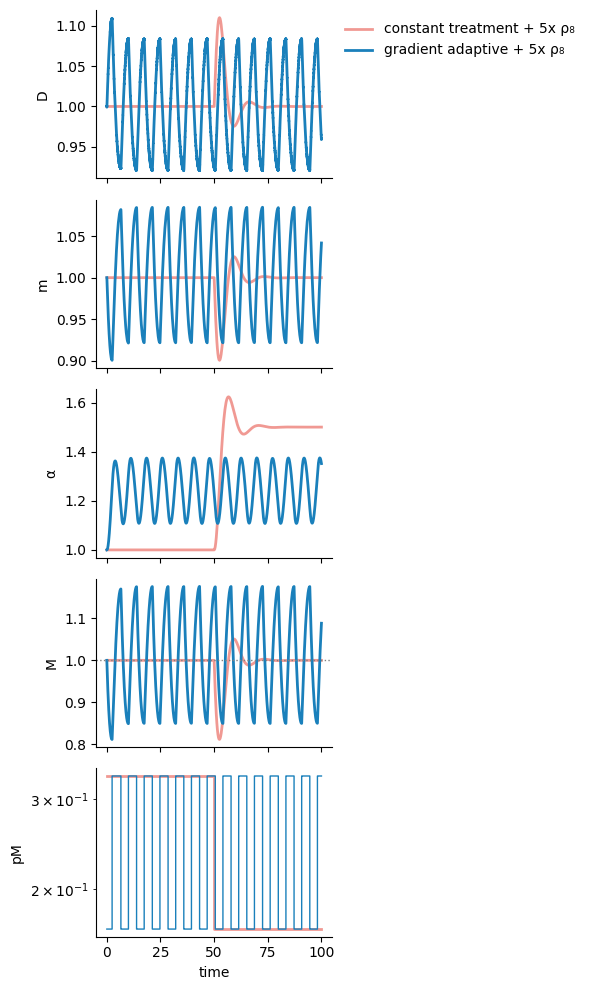

In [45]:
def gradient_adaptive_treatment(params, total_duration, pM_reduction_fold=2, p8_fold=5,
                                initial_treat_duration=1.0):
    """Treat while dM/dt < 0, stop when dM/dt > 0. Uses accelerated memory erasure."""
    p = params.copy()
    p['p8'] = params['p8'] * p8_fold
    p5_base = params['p5']
    p5_treat = p5_base / pM_reduction_fold

    x = get_steady_state(params)

    def f_ivp(t, y):
        return get_f(p)(y, t)

    # Phase 0: initial treatment kick
    p['p5'] = p5_treat
    sol0 = solve_ivp(f_ivp, (0, initial_treat_duration), x, max_step=0.1)

    t_all = [sol0.t]
    sol_all = [sol0.y.T]
    pM_all = [np.full(len(sol0.t), p5_treat)]

    x = sol0.y[:, -1]
    t_start = initial_treat_duration
    treatment_on = True  # started with treatment

    def dM_zero(t, y):
        """dM/dt = 0 event."""
        deriv = get_f(p)(y, t)
        return deriv[3]
    dM_zero.terminal = True
    dM_zero.direction = 0

    max_segments = 500
    for _ in range(max_segments):
        if t_start >= total_duration:
            break

        p['p5'] = p5_treat if treatment_on else p5_base

        # Integrate until dM/dt changes sign
        sol = solve_ivp(f_ivp, (t_start, total_duration), x,
                        max_step=0.1, events=[dM_zero])
        t_all.append(sol.t)
        sol_all.append(sol.y.T)
        pM_all.append(np.full(len(sol.t), p['p5']))
        x = sol.y[:, -1]
        t_start = sol.t[-1]

        if sol.t_events[0].size > 0:
            treatment_on = not treatment_on

    return np.concatenate(t_all), np.vstack(sol_all), np.concatenate(pM_all)


T_total_grad = 100

t_grad, sol_grad, pM_grad = gradient_adaptive_treatment(
    defaults, total_duration=T_total_grad, pM_reduction_fold=pM_reduction_fold)

# Standard constant treatment for comparison (also with 5x p8)
t1_std_g, sol1_std_g, t2_std_g, sol2_std_g, pM_std_g = abrupt_treatment(
    params_5x_p8, baseline_duration=T_total_grad / 2, treat_duration=T_total_grad / 2,
    pM_reduction_fold=pM_reduction_fold)
t_std_g = np.concatenate([t1_std_g, t2_std_g])
sol_std_g = np.vstack([sol1_std_g, sol2_std_g])

var_names = ['D', 'm', 'α', 'M']
fig, axs = plt.subplots(5, 1, figsize=(6, 10), sharex=True)

for i, (ax, name) in enumerate(zip(axs[:4], var_names)):
    ax.plot(t_std_g, sol_std_g[:, i], color=RED, lw=2, label='constant treatment + 5x ρ₈', alpha=0.5)
    ax.plot(t_grad, sol_grad[:, i], color=BLUE, lw=2, label='gradient adaptive + 5x ρ₈')
    if name == 'M':
        ax.axhline(1.0, color='gray', ls=':', lw=1)
    ax.set_ylabel(name)
    if i == 0:
        ax.legend(frameon=False, bbox_to_anchor=(1, 1))
    sns.despine(ax=ax)

ax = axs[4]
ax.plot(t_std_g, pM_std_g, color=RED, lw=2, alpha=0.5)
ax.plot(t_grad, pM_grad, color=BLUE, lw=1)
ax.set_ylabel('pM')
ax.set_xlabel('time')
ax.set_yscale('log')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()